In [1]:
# ============================================================
# Setup: Install Dependencies & Imports
# ============================================================
!pip install -q transformers xgboost wandb

import os, gc, random, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import librosa
import soundfile as sf
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, classification_report, confusion_matrix

import wandb
warnings.filterwarnings('ignore')
%matplotlib inline
sns.set_style('whitegrid')
PALETTE = sns.color_palette('Set3', 10)

# -- Check internet availability --
INTERNET_AVAILABLE = False
try:
    from transformers import ASTFeatureExtractor, ASTForAudioClassification, ASTModel
    _test = ASTFeatureExtractor.from_pretrained(
        'MIT/ast-finetuned-audioset-10-10-0.4593')
    INTERNET_AVAILABLE = True
    del _test
    print('Internet available -- AST fine-tuning ENABLED')
except Exception as e:
    print(f'No internet or AST unavailable: {e}')
    print('Fallback: frozen AST embeddings + XGBoost')
    try:
        from transformers import ASTFeatureExtractor, ASTModel
    except ImportError:
        pass

print(f'PyTorch: {torch.__version__}')
print(f'CUDA: {torch.cuda.is_available()}')

2026-02-26 10:57:31.156922: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772103451.512792      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772103451.609240      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772103452.463114      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772103452.463161      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772103452.463164      24 computation_placer.cc:177] computation placer alr

preprocessor_config.json:   0%|          | 0.00/297 [00:00<?, ?B/s]

Internet available -- AST fine-tuning ENABLED
PyTorch: 2.8.0+cu126
CUDA: True


In [2]:
# ============================================================
# Setup: Configuration & Paths
# ============================================================
SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed()

# -- Device --
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')

# -- Auto-detect environment --
KAGGLE_DATA = Path('/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup')
LOCAL_DATA = Path('/Users/sanskar/dev/DL-GenAI-P/messy_mashup')

if KAGGLE_DATA.exists():
    DATA_DIR = KAGGLE_DATA
    OUTPUT_DIR = Path('/kaggle/working')
    IS_KAGGLE = True
elif LOCAL_DATA.exists():
    DATA_DIR = LOCAL_DATA
    OUTPUT_DIR = LOCAL_DATA.parent / 'outputs'
    IS_KAGGLE = False
else:
    raise FileNotFoundError('Data directory not found.')

GENRES_DIR = DATA_DIR / 'genres_stems'
ESC50_AUDIO_DIR = DATA_DIR / 'ESC-50-master' / 'audio'
TEST_CSV = DATA_DIR / 'test.csv'
FEATURES_DIR = OUTPUT_DIR / 'features'
FEATURES_DIR.mkdir(parents=True, exist_ok=True)

# -- Genre Mapping --
GENRES = ['blues', 'classical', 'country', 'disco', 'hiphop',
          'jazz', 'metal', 'pop', 'reggae', 'rock']
GENRE_TO_IDX = {g: i for i, g in enumerate(GENRES)}
IDX_TO_GENRE = {i: g for g, i in GENRE_TO_IDX.items()}
NUM_CLASSES = len(GENRES)

# -- Audio --
SAMPLE_RATE = 22050
AST_SAMPLE_RATE = 16000
CHUNK_DURATION = 10
CHUNK_SAMPLES = SAMPLE_RATE * CHUNK_DURATION
N_MELS, N_FFT, HOP_LENGTH = 128, 2048, 512
FMIN, FMAX = 20, 8000
N_MFCC = 40

# -- Augmentation --
STEM_NAMES = ['drums.wav', 'vocals.wav', 'bass.wav', 'other.wav']
NOISE_SNR_MIN, NOISE_SNR_MAX = 5, 25
STEM_VOLUME_MIN, STEM_VOLUME_MAX = -6, 6
MIX_STEMS_MIN, MIX_STEMS_MAX = 2, 4
VAL_SONGS_PER_GENRE = 15
ESC50_CACHE_SIZE = 300

# -- AST Fine-tuning --
AST_MODEL_NAME = 'MIT/ast-finetuned-audioset-10-10-0.4593'
AST_EPOCHS = 12
AST_LR = 5e-5
AST_HEAD_LR = 1e-3
AST_BATCH_SIZE = 8
AST_GRAD_ACCUM = 2
AST_SAMPLES_PER_EPOCH = 4000
AST_VAL_SAMPLES = 1000
N_CROPS_TEST = 10

print(f'Device: {DEVICE}')
print(f'Data:   {DATA_DIR}')
print(f'Output: {OUTPUT_DIR}')
# -- W&B config --
WANDB_ENTITY  = "23f3003478-iit-madras"
WANDB_PROJECT = "23f3003478-t12026"
WANDB_API_KEY = "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"

try:
    import wandb
    wandb.login(key=WANDB_API_KEY, relogin=True)
    WANDB_ENABLED = True
    print("W&B: logged in successfully")
except Exception as _e:
    WANDB_ENABLED = False
    print(f"W&B: disabled ({_e})")

def wb_init(**kwargs):
    if not WANDB_ENABLED: return None
    try:
        return wandb.init(project=WANDB_PROJECT, entity=WANDB_ENTITY,
                          reinit="finish_previous", **kwargs)
    except Exception as e:
        print(f"W&B init failed: {e}")
        return None

def wb_log(d, run=None):
    if not WANDB_ENABLED: return
    try: wandb.log(d)
    except Exception: pass

def wb_finish(run):
    if run is None or not WANDB_ENABLED: return
    try: run.finish()
    except Exception: pass


Device: cuda
Data:   /kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup
Output: /kaggle/working


In [3]:
# ============================================================
# Setup: Audio Utility Functions
# ============================================================

def load_audio(path, sr=SAMPLE_RATE, duration=None, offset=0.0):
    try:
        audio, _ = librosa.load(str(path), sr=sr, mono=True,
                                duration=duration, offset=offset)
    except Exception:
        data, orig_sr = sf.read(str(path), always_2d=True)
        audio = data.mean(axis=1).astype(np.float32)
        if orig_sr != sr:
            audio = librosa.resample(audio, orig_sr=orig_sr, target_sr=sr)
    return audio.astype(np.float32)

def pad_or_trim(audio, target_len):
    if len(audio) < target_len:
        return np.pad(audio, (0, target_len - len(audio)), mode='constant')
    return audio[:target_len]

def random_crop(audio, target_len):
    if len(audio) <= target_len:
        return pad_or_trim(audio, target_len)
    start = random.randint(0, len(audio) - target_len)
    return audio[start:start + target_len]

# -- ESC-50 Noise Pool --
_esc50_audio_cache = None

def _build_esc50_audio_cache():
    global _esc50_audio_cache
    if _esc50_audio_cache is not None:
        return _esc50_audio_cache
    paths = sorted(ESC50_AUDIO_DIR.glob('*.wav'))
    if not paths:
        raise FileNotFoundError(f'No ESC-50 files in {ESC50_AUDIO_DIR}')
    rng = random.Random(SEED)
    selected = rng.sample(paths, min(ESC50_CACHE_SIZE, len(paths)))
    cache = []
    for p in selected:
        try:
            cache.append(load_audio(p, sr=SAMPLE_RATE))
        except Exception:
            pass
    _esc50_audio_cache = cache
    print(f'ESC-50 cache: {len(cache)} clips')
    return cache

def load_random_noise(target_len):
    cache = _build_esc50_audio_cache()
    return random_crop(random.choice(cache), target_len)

def add_noise_at_snr(signal, noise, snr_db):
    sig_pow = np.mean(signal ** 2) + 1e-10
    noi_pow = np.mean(noise ** 2) + 1e-10
    target_pow = sig_pow / (10 ** (snr_db / 10))
    return signal + noise * np.sqrt(target_pow / noi_pow)

def add_random_noise(audio, snr_min=NOISE_SNR_MIN, snr_max=NOISE_SNR_MAX):
    noise = load_random_noise(len(audio))
    return add_noise_at_snr(audio, noise, random.uniform(snr_min, snr_max))

def apply_volume_jitter(audio, min_db=STEM_VOLUME_MIN, max_db=STEM_VOLUME_MAX):
    return audio * (10 ** (random.uniform(min_db, max_db) / 20))

def apply_tempo_stretch_fast(audio, rate_min=0.85, rate_max=1.15):
    rate = random.uniform(rate_min, rate_max)
    if abs(rate - 1.0) < 0.02:
        return audio
    orig_len = len(audio)
    resampled = librosa.resample(audio, orig_sr=SAMPLE_RATE,
                                  target_sr=int(SAMPLE_RATE * rate))
    if len(resampled) > orig_len:
        resampled = resampled[:orig_len]
    else:
        resampled = np.pad(resampled, (0, max(0, orig_len - len(resampled))))
    return resampled

def get_stem_path(song_dir, stem_name):
    p = song_dir / stem_name
    if p.exists(): return p
    if stem_name == 'other.wav':
        alt = song_dir / 'others.wav'
        if alt.exists(): return alt
    return None

def build_stem_index():
    index = {}
    for genre in GENRES:
        genre_dir = GENRES_DIR / genre
        if not genre_dir.exists(): continue
        index[genre] = sorted([d for d in genre_dir.iterdir() if d.is_dir()])
    print(f'Stem index: {sum(len(v) for v in index.values())} songs, {len(index)} genres')
    return index

def split_songs_train_val(stem_index, val_per_genre=VAL_SONGS_PER_GENRE, seed=SEED):
    rng = random.Random(seed)
    train_idx, val_idx = {}, {}
    for genre, songs in stem_index.items():
        s = songs.copy(); rng.shuffle(s)
        val_idx[genre] = s[:val_per_genre]
        train_idx[genre] = s[val_per_genre:]
    return train_idx, val_idx

def create_synthetic_mashup(genre, stem_index, target_duration=CHUNK_DURATION,
                            n_mix=None, add_noise=True, apply_volume=True,
                            apply_tempo=False):
    target_len = int(target_duration * SAMPLE_RATE)
    songs = stem_index.get(genre, [])
    if len(songs) < 2:
        raise ValueError(f"Not enough songs for '{genre}'")
    if n_mix is None:
        n_mix = random.randint(MIX_STEMS_MIN, min(MIX_STEMS_MAX, len(songs)))
    n_mix = min(n_mix, len(songs))
    selected = random.sample(songs, n_mix)
    stem_pool = STEM_NAMES[:]; random.shuffle(stem_pool)
    mixed = np.zeros(target_len, dtype=np.float32)
    n_mixed = 0
    for i, song_dir in enumerate(selected):
        stem_path = get_stem_path(song_dir, stem_pool[i % len(stem_pool)])
        if stem_path is None:
            for sn in STEM_NAMES:
                stem_path = get_stem_path(song_dir, sn)
                if stem_path: break
        if stem_path is None: continue
        try:
            load_dur = target_duration * 1.3 if apply_tempo else target_duration
            stem_audio = load_audio(stem_path, sr=SAMPLE_RATE, duration=load_dur)
        except Exception: continue
        if len(stem_audio) < 1000: continue
        if apply_tempo and random.random() > 0.3:
            stem_audio = apply_tempo_stretch_fast(stem_audio)
        stem_audio = random_crop(stem_audio, target_len)
        if apply_volume:
            stem_audio = apply_volume_jitter(stem_audio)
        mixed += stem_audio; n_mixed += 1
    if n_mixed == 0:
        return np.zeros(target_len, dtype=np.float32), genre
    mx = np.abs(mixed).max()
    if mx > 0: mixed = mixed / mx * 0.9
    if add_noise:
        mixed = add_random_noise(mixed)
        mx = np.abs(mixed).max()
        if mx > 0: mixed = mixed / mx * 0.9
    return mixed.astype(np.float32), genre

print('Audio utilities loaded.')

Audio utilities loaded.


In [4]:
# ============================================================
# Setup: Feature Extraction Functions
# ============================================================

def extract_mfcc_features(audio, sr=SAMPLE_RATE, n_mfcc=N_MFCC):
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc)
    delta = librosa.feature.delta(mfcc)
    delta2 = librosa.feature.delta(mfcc, order=2)
    features = [mfcc.mean(1), mfcc.std(1), delta.mean(1), delta.std(1),
                delta2.mean(1), delta2.std(1)]
    return np.concatenate(features).astype(np.float32)

def extract_chroma_features(audio, sr=SAMPLE_RATE):
    chroma = librosa.feature.chroma_stft(y=audio, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH)
    return np.concatenate([chroma.mean(1), chroma.std(1)]).astype(np.float32)

def extract_spectral_features(audio, sr=SAMPLE_RATE):
    parts = [
        librosa.feature.spectral_centroid(y=audio, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH),
        librosa.feature.spectral_bandwidth(y=audio, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH),
        librosa.feature.spectral_rolloff(y=audio, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH),
        librosa.feature.spectral_contrast(y=audio, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH),
        librosa.feature.rms(y=audio, hop_length=HOP_LENGTH),
    ]
    feats = []
    for p in parts:
        feats.extend([p.mean(1), p.std(1)])
    return np.concatenate(feats).astype(np.float32)

def extract_full_features(audio, sr=SAMPLE_RATE):
    return np.concatenate([
        extract_mfcc_features(audio, sr),
        extract_chroma_features(audio, sr),
        extract_spectral_features(audio, sr),
    ]).astype(np.float32)

def audio_to_melspec(audio, sr=SAMPLE_RATE):
    mel = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=N_MELS,
        n_fft=N_FFT, hop_length=HOP_LENGTH, fmin=FMIN, fmax=FMAX)
    return librosa.power_to_db(mel, ref=np.max, top_db=80.0).astype(np.float32)

def melspec_for_cnn(audio, target_frames=431):
    mel = audio_to_melspec(audio)
    if mel.shape[1] < target_frames:
        mel = np.pad(mel, ((0,0),(0, target_frames - mel.shape[1])),
                     mode='constant', constant_values=mel.min())
    else:
        mel = mel[:, :target_frames]
    mn, mx = mel.min(), mel.max()
    if mx - mn > 1e-6:
        mel = (mel - mn) / (mx - mn)
    else:
        mel = np.zeros_like(mel)
    return mel[np.newaxis, :, :].astype(np.float32)

print('Feature extraction functions loaded.')

Feature extraction functions loaded.


In [5]:
# ============================================================
# Setup: Visualization Helpers
# ============================================================

def plot_confusion_matrix(y_true, y_pred, title='Confusion Matrix'):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=GENRES, yticklabels=GENRES, ax=ax)
    ax.set_xlabel('Predicted', fontsize=12)
    ax.set_ylabel('True', fontsize=12)
    ax.set_title(title, fontsize=14)
    plt.tight_layout()
    plt.show()

def plot_per_class_f1(y_true, y_pred, title='Per-Class F1 Score'):
    per_class = f1_score(y_true, y_pred, average=None, labels=list(range(NUM_CLASSES)))
    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(GENRES, per_class, color=PALETTE)
    ax.set_ylabel('F1 Score', fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis='x', rotation=45)
    for bar, val in zip(bars, per_class):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                '%.2f' % val, ha='center', va='bottom', fontsize=9)
    macro = f1_score(y_true, y_pred, average='macro')
    ax.axhline(y=macro, color='red', linestyle='--', alpha=0.7, label='Macro F1 = %.3f' % macro)
    ax.legend(fontsize=11)
    plt.tight_layout()
    plt.show()

def plot_training_curves(history, title_prefix=''):
    n_epochs = len(history['val_f1'])
    epochs = range(1, n_epochs + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    if 'train_loss' in history and history['train_loss']:
        axes[0].plot(epochs, history['train_loss'], 'b-o', label='Train', markersize=4)
    if 'val_loss' in history and history['val_loss']:
        axes[0].plot(epochs, history['val_loss'], 'r-o', label='Val', markersize=4)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title(title_prefix + ' Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    if 'train_f1' in history and history['train_f1']:
        axes[1].plot(epochs, history['train_f1'], 'b-o', label='Train', markersize=4)
    axes[1].plot(epochs, history['val_f1'], 'r-o', label='Val', markersize=4)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Macro F1')
    axes[1].set_title(title_prefix + ' Macro F1')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def sync_and_clear(device):
    if device.type == 'mps':
        torch.mps.synchronize(); torch.mps.empty_cache()
    elif device.type == 'cuda':
        torch.cuda.synchronize(); torch.cuda.empty_cache()
    gc.collect()

print('Visualization helpers loaded.')

Visualization helpers loaded.


# Milestone 1: Exploratory Data Analysis
### Exploring the training data structure, generate synthetic mashups to simulate test conditions, and visualize the audio characteristics across genres.

In [6]:
# ============================================================
# M1: Data Overview
# ============================================================
set_seed()
stem_index = build_stem_index()
train_index, val_index = split_songs_train_val(stem_index)

print('Songs per genre:')
for g in GENRES:
    total = len(stem_index.get(g, []))
    tr = len(train_index.get(g, []))
    va = len(val_index.get(g, []))
    print(f'  {g:12s}: {total} total, {tr} train, {va} val')

test_df = pd.read_csv(TEST_CSV)
print(f'\nTest files: {len(test_df)}')
print(f'Test columns: {list(test_df.columns)}')
print(test_df.head())

# Random baseline
print(f'\nRandom Baseline: ~{1.0/NUM_CLASSES:.2f} Macro F1 (by definition for {NUM_CLASSES} classes)')

# Generate a few sample mashups for visualization
sample_mashups = {}
for g in GENRES:
    audio, _ = create_synthetic_mashup(g, train_index, add_noise=True)
    sample_mashups[g] = audio
print(f'\nGenerated {len(sample_mashups)} sample mashups for visualization.')

Stem index: 1000 songs, 10 genres
Songs per genre:
  blues       : 100 total, 85 train, 15 val
  classical   : 100 total, 85 train, 15 val
  country     : 100 total, 85 train, 15 val
  disco       : 100 total, 85 train, 15 val
  hiphop      : 100 total, 85 train, 15 val
  jazz        : 100 total, 85 train, 15 val
  metal       : 100 total, 85 train, 15 val
  pop         : 100 total, 85 train, 15 val
  reggae      : 100 total, 85 train, 15 val
  rock        : 100 total, 85 train, 15 val

Test files: 3020
Test columns: ['id', 'filename']
   id              filename
0   1  mashups/song0001.wav
1   2  mashups/song0002.wav
2   3  mashups/song0003.wav
3   4  mashups/song0004.wav
4   5  mashups/song0005.wav

Random Baseline: ~0.10 Macro F1 (by definition for 10 classes)
ESC-50 cache: 300 clips

Generated 10 sample mashups for visualization.


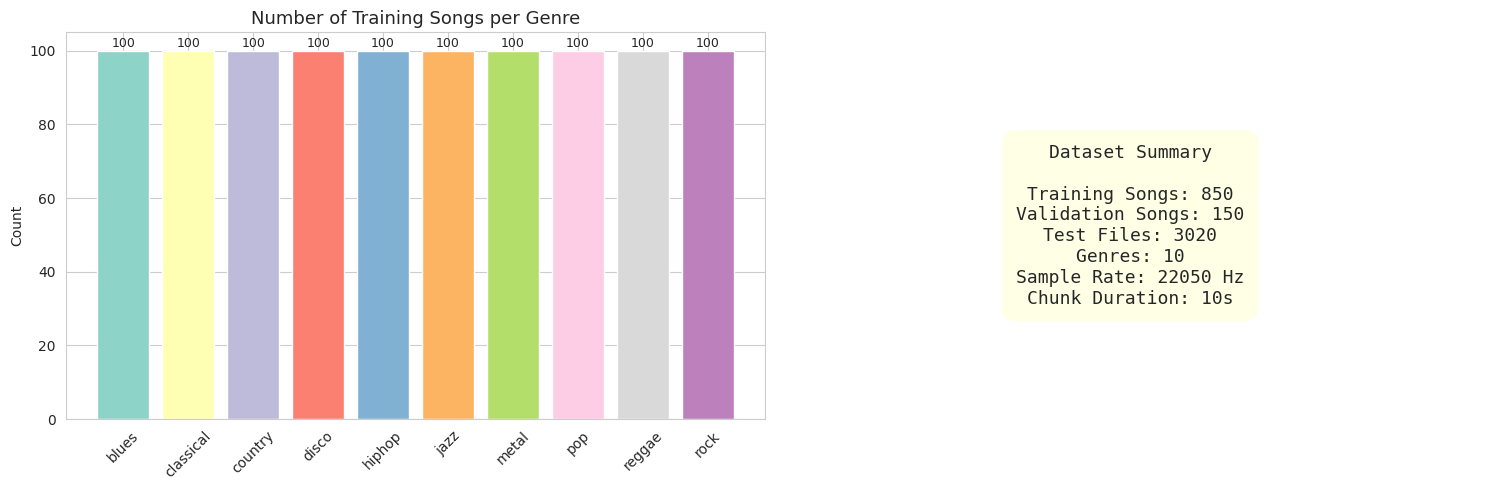

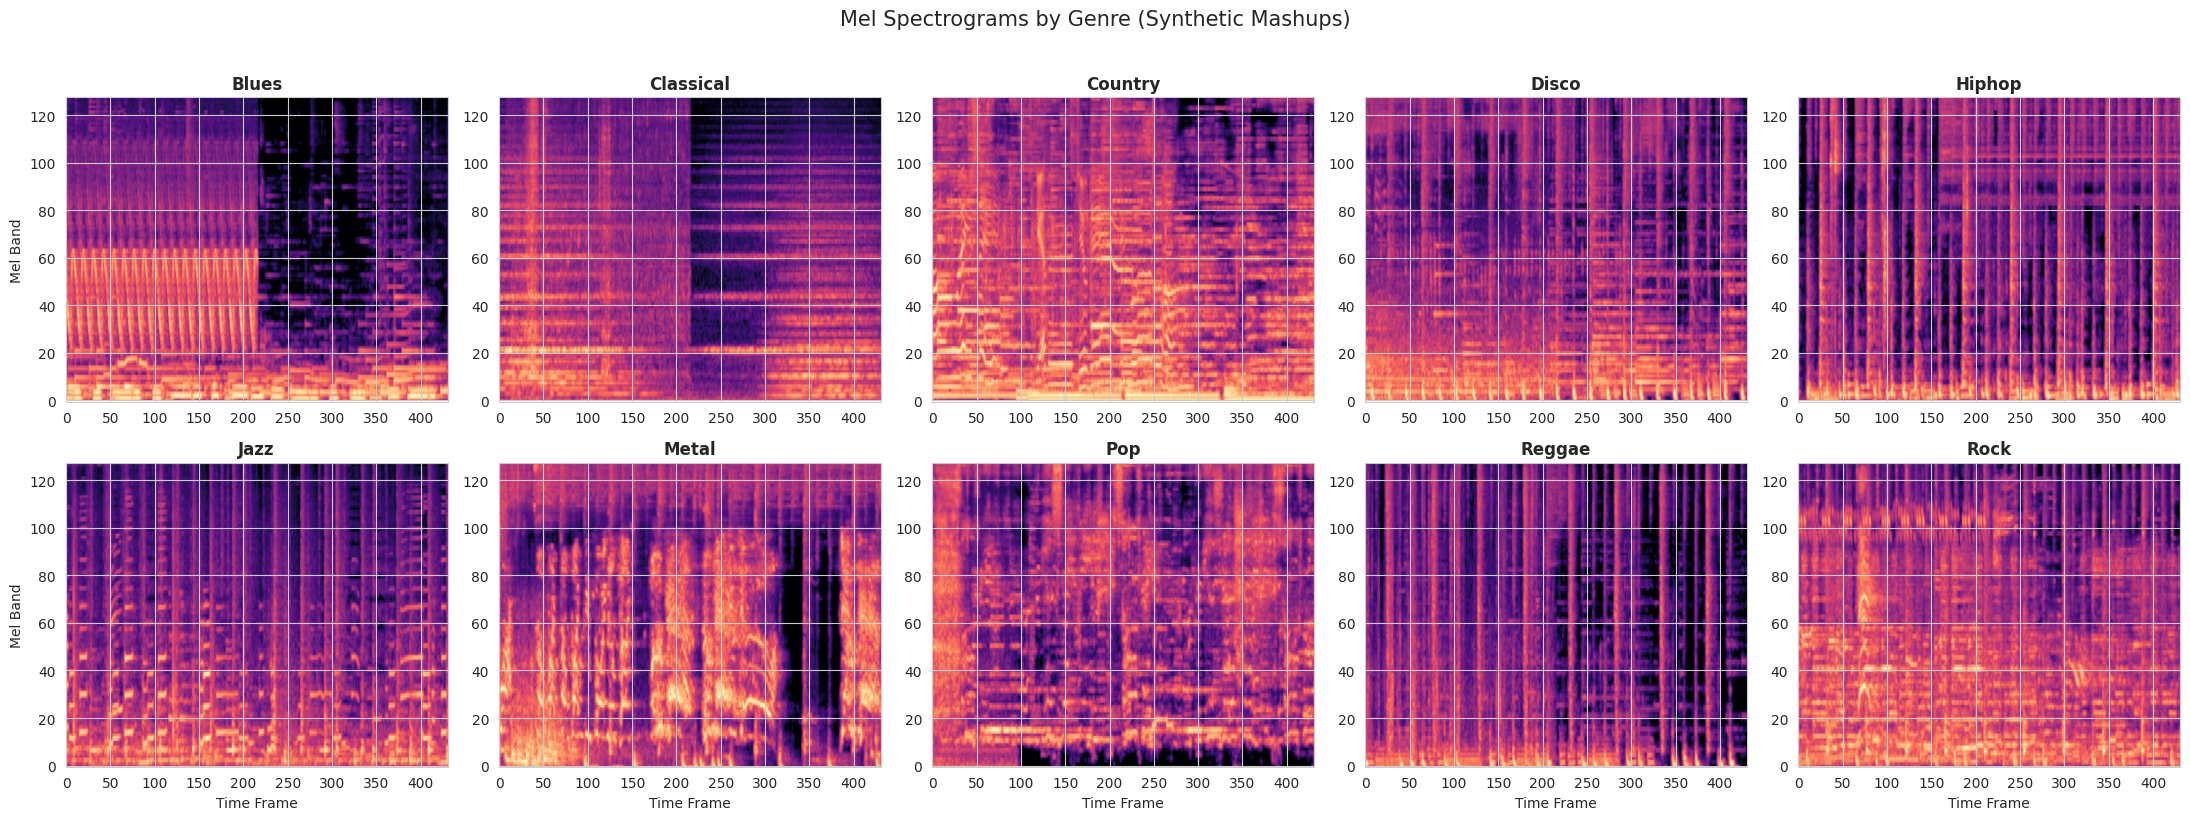

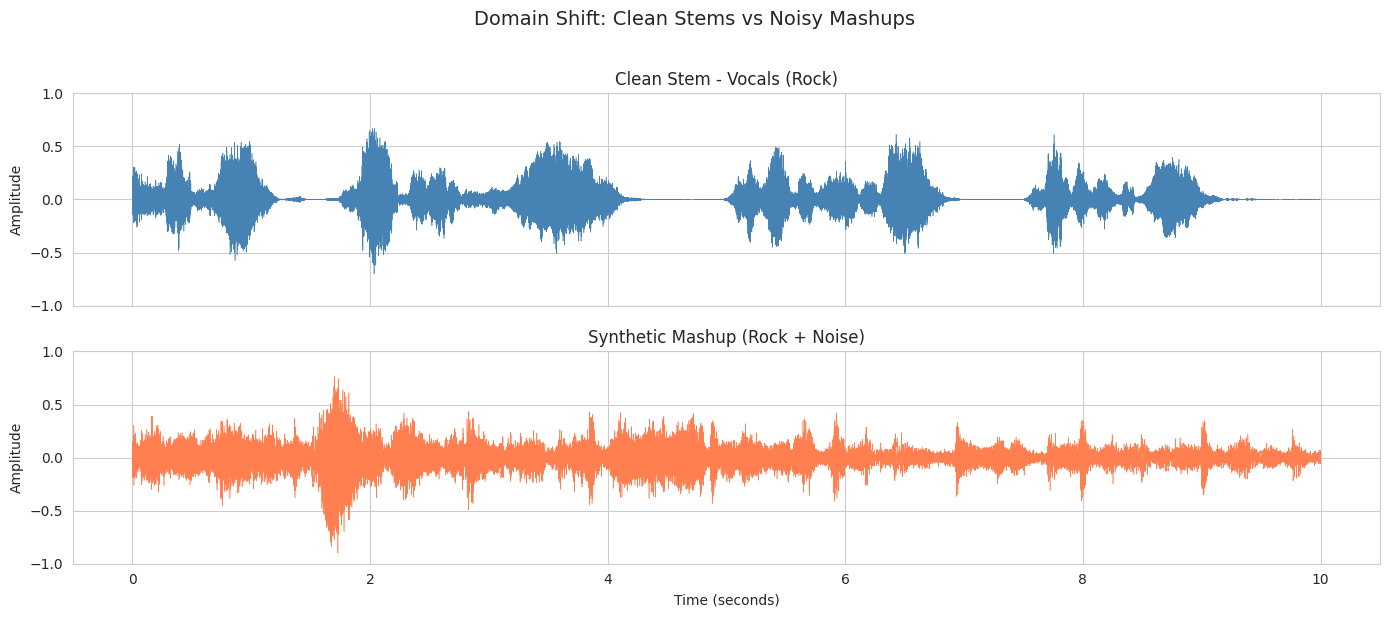

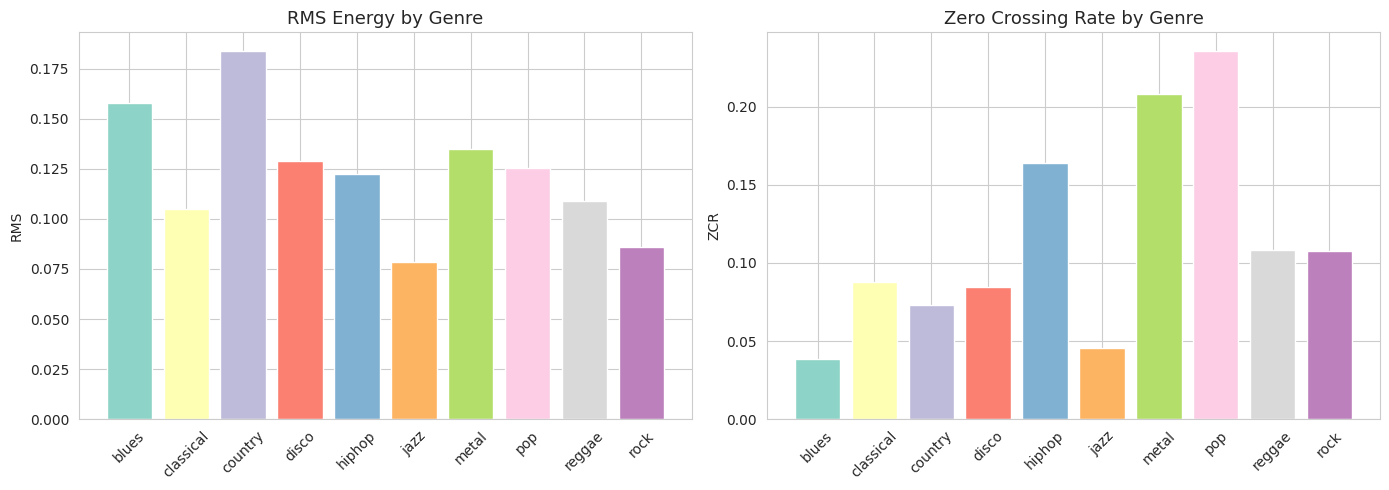

M1 EDA complete.


In [7]:
# ============================================================
# M1: EDA Visualizations
# ============================================================

# --- 1. Genre Distribution ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
genre_counts = [len(stem_index.get(g, [])) for g in GENRES]
axes[0].bar(GENRES, genre_counts, color=PALETTE)
axes[0].set_title('Number of Training Songs per Genre', fontsize=13)
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(genre_counts):
    axes[0].text(i, v + 1, str(v), ha='center', fontsize=9)

# Dataset summary
info_lines = [
    'Dataset Summary',
    '',
    'Training Songs: %d' % sum(len(v) for v in train_index.values()),
    'Validation Songs: %d' % sum(len(v) for v in val_index.values()),
    'Test Files: %d' % len(test_df),
    'Genres: %d' % NUM_CLASSES,
    'Sample Rate: %d Hz' % SAMPLE_RATE,
    'Chunk Duration: %ds' % CHUNK_DURATION,
]
axes[1].text(0.5, 0.5, '\n'.join(info_lines), ha='center', va='center',
             fontsize=13, transform=axes[1].transAxes, family='monospace',
             bbox=dict(boxstyle='round,pad=0.8', facecolor='lightyellow', alpha=0.8))
axes[1].axis('off')
plt.tight_layout()
plt.show()

# --- 2. Mel Spectrograms across Genres ---
fig, axes = plt.subplots(2, 5, figsize=(22, 8))
for i, genre in enumerate(GENRES):
    ax = axes[i // 5][i % 5]
    mel = audio_to_melspec(sample_mashups[genre])
    im = ax.imshow(mel, aspect='auto', origin='lower', cmap='magma')
    ax.set_title(genre.capitalize(), fontsize=12, fontweight='bold')
    if i >= 5: ax.set_xlabel('Time Frame')
    if i % 5 == 0: ax.set_ylabel('Mel Band')
fig.suptitle('Mel Spectrograms by Genre (Synthetic Mashups)', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

# --- 3. Waveform Comparison: Clean Stem vs Synthetic Mashup ---                                                                                                                                                                                   
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)                                                                                                                                                                                       
# Pick the stem with the most energy (e.g. drums is silent for classical)    
sample_song = list(train_index['rock'])[0]                                                                                                                                                                                                         
best_stem, best_rms, clean = None, -1, None                                                                                                                                                                                                        
for sn in STEM_NAMES:
  sp = get_stem_path(sample_song, sn)
  if sp:
      a = load_audio(str(sp), duration=CHUNK_DURATION)
      rms = float(np.sqrt(np.mean(a**2)))
      if rms > best_rms:
          best_rms = rms
          best_stem = sn
          clean = a
t_clean = np.linspace(0, len(clean)/SAMPLE_RATE, len(clean))
axes[0].plot(t_clean, clean, color='steelblue', linewidth=0.4)
axes[0].set_title('Clean Stem - %s (Rock)' % best_stem.replace('.wav', '').capitalize(), fontsize=12)
axes[0].set_ylabel('Amplitude')
axes[0].set_ylim(-1, 1)

mashup = sample_mashups['rock']
t_mash = np.linspace(0, len(mashup)/SAMPLE_RATE, len(mashup))
axes[1].plot(t_mash, mashup, color='coral', linewidth=0.4)
axes[1].set_title('Synthetic Mashup (Rock + Noise)', fontsize=12)
axes[1].set_ylabel('Amplitude')
axes[1].set_xlabel('Time (seconds)')
axes[1].set_ylim(-1, 1)
fig.suptitle('Domain Shift: Clean Stems vs Noisy Mashups', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# --- 4. Audio Statistics ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
rms_vals = [np.sqrt(np.mean(sample_mashups[g]**2)) for g in GENRES]
axes[0].bar(GENRES, rms_vals, color=PALETTE)
axes[0].set_title('RMS Energy by Genre', fontsize=13)
axes[0].set_ylabel('RMS')
axes[0].tick_params(axis='x', rotation=45)

zcr_vals = [np.mean(librosa.feature.zero_crossing_rate(sample_mashups[g])) for g in GENRES]
axes[1].bar(GENRES, zcr_vals, color=PALETTE)
axes[1].set_title('Zero Crossing Rate by Genre', fontsize=13)
axes[1].set_ylabel('ZCR')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

print('M1 EDA complete.')

# Milestone 2: Classical ML Baseline (MFCC + XGBoost)
### Extract hand-crafted audio features (MFCC, chroma, spectral) from synthetic mashups, then train an XGBoost classifier. This establishes a classical ML baseline.

In [8]:
# ============================================================
# M2: Classical ML - MFCC + XGBoost
# ============================================================
set_seed()
N_ML_TRAIN, N_ML_VAL = 2000, 500

def generate_ml_features(split_index, n_samples, name):
    n_per = n_samples // NUM_CLASSES
    extra = n_samples % NUM_CLASSES
    feats, labels, failed = [], [], 0
    t0 = time.time()
    total = 0
    for gi, genre in enumerate(sorted(split_index.keys())):
        n = n_per + (1 if gi < extra else 0)
        for _ in range(n):
            total += 1
            try:
                audio, _ = create_synthetic_mashup(genre, split_index, add_noise=True)
                feats.append(extract_full_features(audio))
                labels.append(GENRE_TO_IDX[genre])
            except Exception:
                failed += 1
            if total % 500 == 0:
                rate = total / (time.time() - t0)
                print(f'  {name}: {total}/{n_samples} ({rate:.1f}/s)')
    if failed: print(f'  {name}: {failed} failed')
    return np.array(feats, dtype=np.float32), np.array(labels, dtype=np.int32)

print('Generating ML features...')
X_train_ml, y_train_ml = generate_ml_features(train_index, N_ML_TRAIN, 'Train')
X_val_ml, y_val_ml = generate_ml_features(val_index, N_ML_VAL, 'Val')
print(f'Train: {X_train_ml.shape}, Val: {X_val_ml.shape}')

# Train XGBoost
scaler_ml = StandardScaler()
X_tr_s = scaler_ml.fit_transform(X_train_ml)
X_va_s = scaler_ml.transform(X_val_ml)

# W&B run
wb_m2 = wb_init(
    project=WANDB_PROJECT, entity=WANDB_ENTITY,
    name="xgboost-mfcc",
    config={"model": "XGBoost", "features": "MFCC+Chroma+Spectral",
            "n_estimators": 500, "max_depth": 6, "lr": 0.05,
            "n_train": N_ML_TRAIN, "n_val": N_ML_VAL, "feature_dim": X_train_ml.shape[1]},
    )

t0_m2 = time.time()
xgb_ml = XGBClassifier(n_estimators=500, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8, random_state=SEED, n_jobs=-1, verbosity=0,
    eval_metric='mlogloss')
xgb_ml.fit(X_tr_s, y_train_ml,
            eval_set=[(X_tr_s, y_train_ml), (X_va_s, y_val_ml)],
            verbose=False)

# Log per-round loss curves
evals = xgb_ml.evals_result()
tr_losses = evals['validation_0']['mlogloss']
va_losses = evals['validation_1']['mlogloss']
log_every = max(1, len(tr_losses) // 20)   # log ~20 points
for i in range(0, len(tr_losses), log_every):
    wb_log({
        "n_estimators": i + 1,
        "train/loss":   round(tr_losses[i], 4),
        "val/loss":     round(va_losses[i], 4),
    })

m2_preds = xgb_ml.predict(X_va_s)
ml_val_f1 = f1_score(y_val_ml, m2_preds, average='macro')
per_class_f1 = f1_score(y_val_ml, m2_preds, average=None, labels=list(range(NUM_CLASSES)))

# Final metrics
wb_log({
    "val/f1": ml_val_f1,
    "train/f1": f1_score(y_train_ml, xgb_ml.predict(X_tr_s), average='macro'),
    "best_val_f1": ml_val_f1,
    "training_time_s": time.time() - t0_m2,
    **{f"val_f1/{GENRES[i]}": per_class_f1[i] for i in range(NUM_CLASSES)},
})
wb_finish(wb_m2)

print(f'\nM2 XGBoost Val Macro F1: {ml_val_f1:.4f}')
print(classification_report(y_val_ml, m2_preds, target_names=GENRES, digits=3))


Generating ML features...
  Train: 500/2000 (4.6/s)
  Train: 1000/2000 (4.6/s)
  Train: 1500/2000 (4.6/s)
  Train: 2000/2000 (4.6/s)
  Val: 500/500 (4.5/s)
Train: (2000, 286), Val: (500, 286)

M2 XGBoost Val Macro F1: 0.5710
              precision    recall  f1-score   support

       blues      0.549     0.560     0.554        50
   classical      0.911     0.820     0.863        50
     country      0.415     0.340     0.374        50
       disco      0.531     0.520     0.525        50
      hiphop      0.566     0.600     0.583        50
        jazz      0.608     0.620     0.614        50
       metal      0.712     0.740     0.725        50
         pop      0.603     0.760     0.673        50
      reggae      0.537     0.580     0.558        50
        rock      0.268     0.220     0.242        50

    accuracy                          0.576       500
   macro avg      0.570     0.576     0.571       500
weighted avg      0.570     0.576     0.571       500



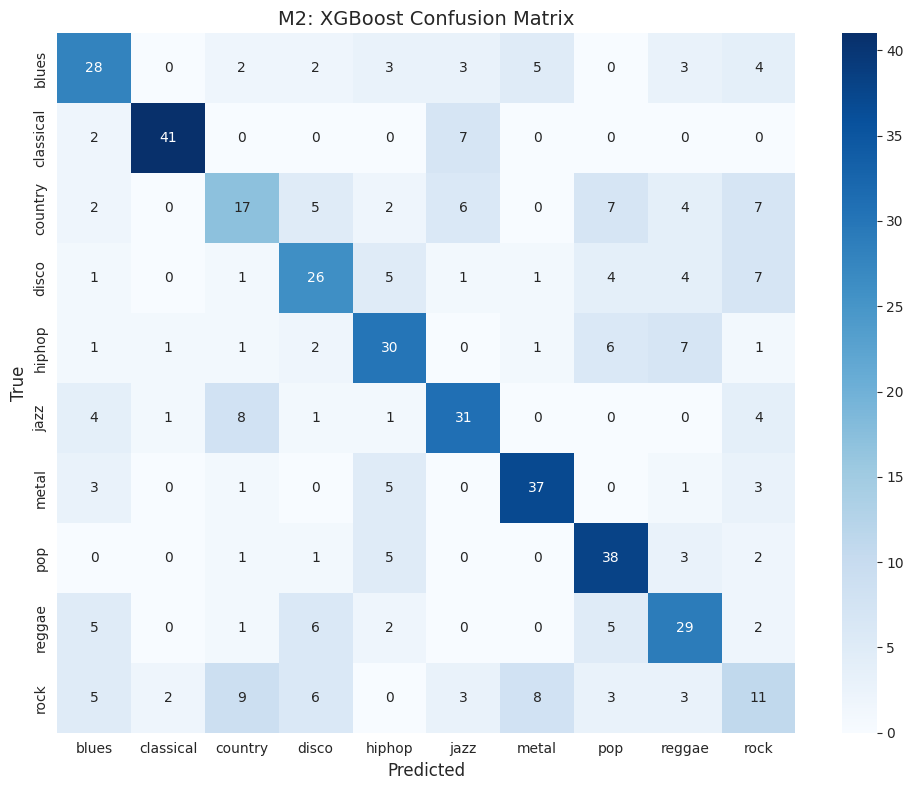

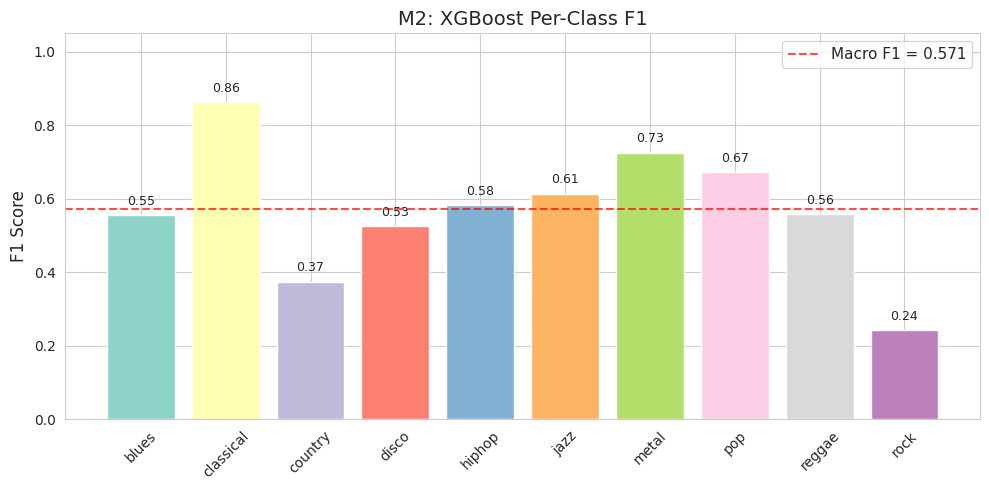

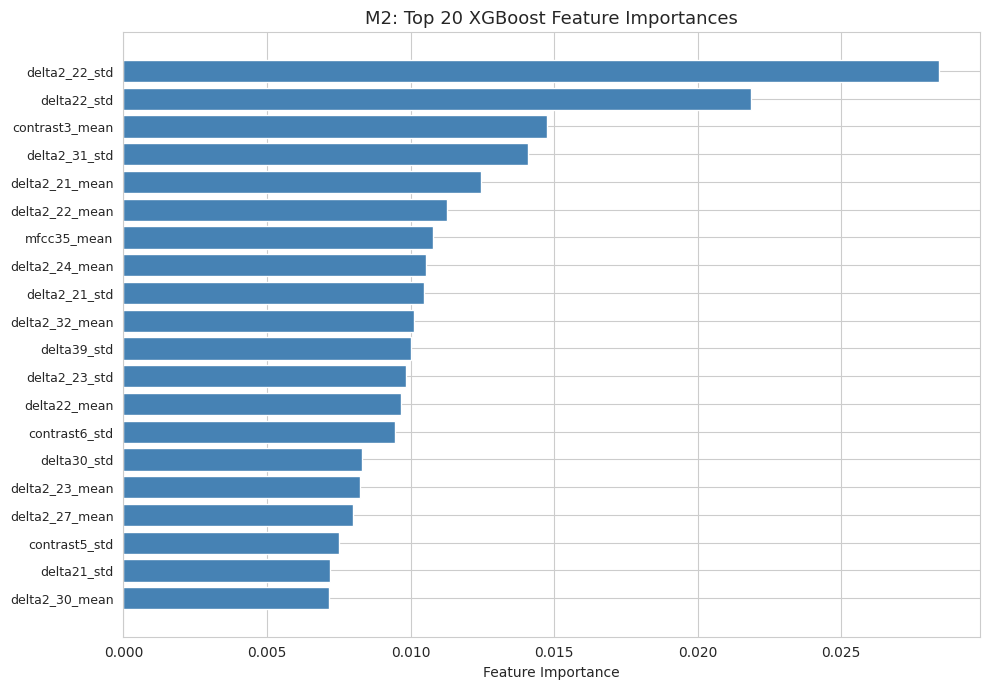

M2 complete. Val Macro F1: 0.5710


In [9]:
# ============================================================
# M2: Visualizations
# ============================================================
plot_confusion_matrix(y_val_ml, m2_preds, 'M2: XGBoost Confusion Matrix')
plot_per_class_f1(y_val_ml, m2_preds, 'M2: XGBoost Per-Class F1')

# Feature importance (top 20)
importances = xgb_ml.feature_importances_
top_idx = np.argsort(importances)[-20:]
feat_names = []
for i in range(N_MFCC):
    for stat in ['mean', 'std']:
        feat_names.append(f'mfcc{i}_{stat}')
for i in range(N_MFCC):
    for stat in ['mean', 'std']:
        feat_names.append(f'delta{i}_{stat}')
for i in range(N_MFCC):
    for stat in ['mean', 'std']:
        feat_names.append(f'delta2_{i}_{stat}')
for i in range(12):
    for stat in ['mean', 'std']:
        feat_names.append(f'chroma{i}_{stat}')
for name in ['centroid', 'bandwidth', 'rolloff']:
    for stat in ['mean', 'std']:
        feat_names.append(f'{name}_{stat}')
for i in range(7):
    for stat in ['mean', 'std']:
        feat_names.append(f'contrast{i}_{stat}')
for stat in ['mean', 'std']:
    feat_names.append(f'rms_{stat}')
# Truncate or extend to match
while len(feat_names) < len(importances):
    feat_names.append(f'feat_{len(feat_names)}')
feat_names = feat_names[:len(importances)]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(range(len(top_idx)), importances[top_idx], color='steelblue')
ax.set_yticks(range(len(top_idx)))
ax.set_yticklabels([feat_names[i] for i in top_idx], fontsize=9)
ax.set_xlabel('Feature Importance')
ax.set_title('M2: Top 20 XGBoost Feature Importances', fontsize=13)
plt.tight_layout()
plt.show()

print(f'M2 complete. Val Macro F1: {ml_val_f1:.4f}')

# Milestone 3: CNN on Mel Spectrograms
### Train a SimpleCNN (4 conv blocks) on log-mel spectrograms generated from synthetic mashups. This explores deep learning without pretrained weights.

In [10]:
# ============================================================
# M3: SimpleCNN & Training Utilities
# ============================================================

class LabelSmoothingCrossEntropy(nn.Module):
    def __init__(self, smoothing=0.1):
        super().__init__()
        self.smoothing = smoothing
    def forward(self, logits, targets):
        n_classes = logits.size(-1)
        log_probs = torch.log_softmax(logits, dim=-1)
        smooth = torch.full_like(log_probs, self.smoothing / (n_classes - 1))
        smooth.scatter_(-1, targets.unsqueeze(-1), 1.0 - self.smoothing)
        return -(smooth * log_probs).sum(dim=-1).mean()

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.1),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.1),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.2),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Dropout(0.3),
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(128, num_classes),
        )
    def forward(self, x):
        return self.classifier(self.features(x))

class SpecDataset(Dataset):
    def __init__(self, specs, labels):
        self.specs = torch.FloatTensor(specs)
        self.labels = torch.LongTensor(labels)
    def __len__(self): return len(self.labels)
    def __getitem__(self, i): return self.specs[i], self.labels[i]

print('SimpleCNN defined: %.1fK params' % (sum(p.numel() for p in SimpleCNN().parameters()) / 1e3))

SimpleCNN defined: 423.0K params


In [11]:
# ============================================================
# M3: CNN Training
# ============================================================
set_seed()
N_CNN_TRAIN, N_CNN_VAL = 5000, 1000
CNN_EPOCHS = 10

def generate_specs(split_index, n_samples, name):
    n_per = n_samples // NUM_CLASSES
    specs, labels = [], []
    t0 = time.time()
    total = 0
    for gi, genre in enumerate(sorted(split_index.keys())):
        for _ in range(n_per):
            total += 1
            try:
                audio, _ = create_synthetic_mashup(genre, split_index, add_noise=True)
                specs.append(melspec_for_cnn(audio))
                labels.append(GENRE_TO_IDX[genre])
            except Exception: pass
            if total % 1000 == 0:
                print(f'  {name}: {total}/{n_samples} ({total/(time.time()-t0):.1f}/s)')
    return np.array(specs), np.array(labels, dtype=np.int32)

print('Generating mel spectrograms...')
train_specs, train_labels = generate_specs(train_index, N_CNN_TRAIN, 'Train')
val_specs, val_labels = generate_specs(val_index, N_CNN_VAL, 'Val')
print(f'Train specs: {train_specs.shape}, Val specs: {val_specs.shape}')

# W&B run
wb_m3 = wb_init(
    project=WANDB_PROJECT, entity=WANDB_ENTITY,
    name="simplecnn-melspec",
    config={"model": "SimpleCNN", "n_params": sum(p.numel() for p in SimpleCNN().parameters()),
            "lr": 3e-4, "weight_decay": 1e-4, "epochs": CNN_EPOCHS,
            "batch_size": 32, "scheduler": "CosineAnnealingLR",
            "loss": "LabelSmoothingCrossEntropy(eps=0.1)",
            "n_train": N_CNN_TRAIN, "n_val": N_CNN_VAL,
            "input_shape": "(1,128,431)"},
    )

cnn = SimpleCNN().to(DEVICE)
cnn_opt = torch.optim.AdamW(cnn.parameters(), lr=3e-4, weight_decay=1e-4)
cnn_sched = torch.optim.lr_scheduler.CosineAnnealingLR(cnn_opt, T_max=CNN_EPOCHS)
cnn_criterion = LabelSmoothingCrossEntropy(smoothing=0.1)

train_dl = DataLoader(SpecDataset(train_specs, train_labels), batch_size=32, shuffle=True)
val_dl = DataLoader(SpecDataset(val_specs, val_labels), batch_size=64)

cnn_best_f1 = 0.0
cnn_history = {'train_loss': [], 'val_loss': [], 'val_f1': []}
m3_val_preds, m3_val_trues = None, None

for epoch in range(1, CNN_EPOCHS + 1):
    cnn.train()
    epoch_loss = 0.0
    n_batches = 0
    for xb, yb in train_dl:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        loss = cnn_criterion(cnn(xb), yb)
        cnn_opt.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(cnn.parameters(), 1.0)
        cnn_opt.step()
        epoch_loss += loss.item()
        n_batches += 1
    cnn_sched.step()

    cnn.eval()
    preds, trues = [], []
    val_loss_sum = 0.0
    vn = 0
    with torch.no_grad():
        for xb, yb in val_dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = cnn(xb)
            val_loss_sum += cnn_criterion(logits, yb).item()
            vn += 1
            preds.extend(logits.argmax(1).cpu().numpy())
            trues.extend(yb.cpu().numpy())
    vf1 = f1_score(trues, preds, average='macro')
    cnn_history['train_loss'].append(epoch_loss / n_batches)
    cnn_history['val_loss'].append(val_loss_sum / vn)
    cnn_history['val_f1'].append(vf1)
    if vf1 > cnn_best_f1:
        cnn_best_f1 = vf1
        m3_val_preds = np.array(preds)
        m3_val_trues = np.array(trues)
    print(f'  Epoch {epoch:2d}/{CNN_EPOCHS} | Train Loss: {epoch_loss/n_batches:.4f} | Val Loss: {val_loss_sum/vn:.4f} | Val F1: {vf1:.4f}')
    wb_log({
        "epoch": epoch,
        "train/loss": round(epoch_loss / n_batches, 4),
        "val/loss":   round(val_loss_sum / vn, 4),
        "val/f1":     round(vf1, 4),
        "learning_rate": cnn_sched.get_last_lr()[0],
        "best_val_f1": round(cnn_best_f1, 4),
    })
    sync_and_clear(DEVICE)

print(f'\nM3 CNN Best Val F1: {cnn_best_f1:.4f}')
if m3_val_preds is not None:
    pc_f1 = f1_score(m3_val_trues, m3_val_preds, average=None, labels=list(range(NUM_CLASSES)))
    wb_log({f"val_f1/{GENRES[i]}": pc_f1[i] for i in range(NUM_CLASSES)})
wb_finish(wb_m3)

# Free CNN memory
del train_specs, val_specs, train_dl, val_dl, cnn
sync_and_clear(DEVICE)

Generating mel spectrograms...
  Train: 1000/5000 (12.0/s)
  Train: 2000/5000 (12.0/s)
  Train: 3000/5000 (11.9/s)
  Train: 4000/5000 (11.9/s)
  Train: 5000/5000 (11.9/s)
  Val: 1000/1000 (12.4/s)
Train specs: (5000, 1, 128, 431), Val specs: (1000, 1, 128, 431)
  Epoch  1/10 | Train Loss: 2.1416 | Val Loss: 2.0245 | Val F1: 0.2175
  Epoch  2/10 | Train Loss: 2.0050 | Val Loss: 1.9465 | Val F1: 0.2668
  Epoch  3/10 | Train Loss: 1.9684 | Val Loss: 1.9289 | Val F1: 0.2553
  Epoch  4/10 | Train Loss: 1.9337 | Val Loss: 1.8796 | Val F1: 0.3269
  Epoch  5/10 | Train Loss: 1.9166 | Val Loss: 1.9011 | Val F1: 0.2827
  Epoch  6/10 | Train Loss: 1.9025 | Val Loss: 1.8592 | Val F1: 0.3179
  Epoch  7/10 | Train Loss: 1.8850 | Val Loss: 1.8734 | Val F1: 0.3039
  Epoch  8/10 | Train Loss: 1.8682 | Val Loss: 1.8440 | Val F1: 0.3351
  Epoch  9/10 | Train Loss: 1.8687 | Val Loss: 1.8408 | Val F1: 0.3369
  Epoch 10/10 | Train Loss: 1.8627 | Val Loss: 1.8440 | Val F1: 0.3287

M3 CNN Best Val F1: 0.3369


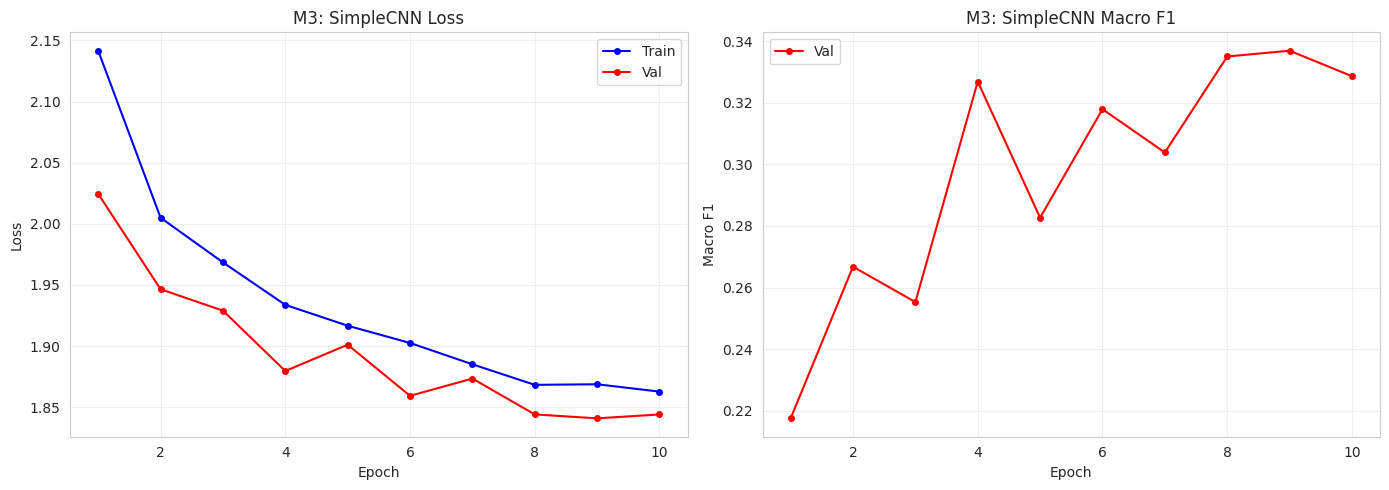

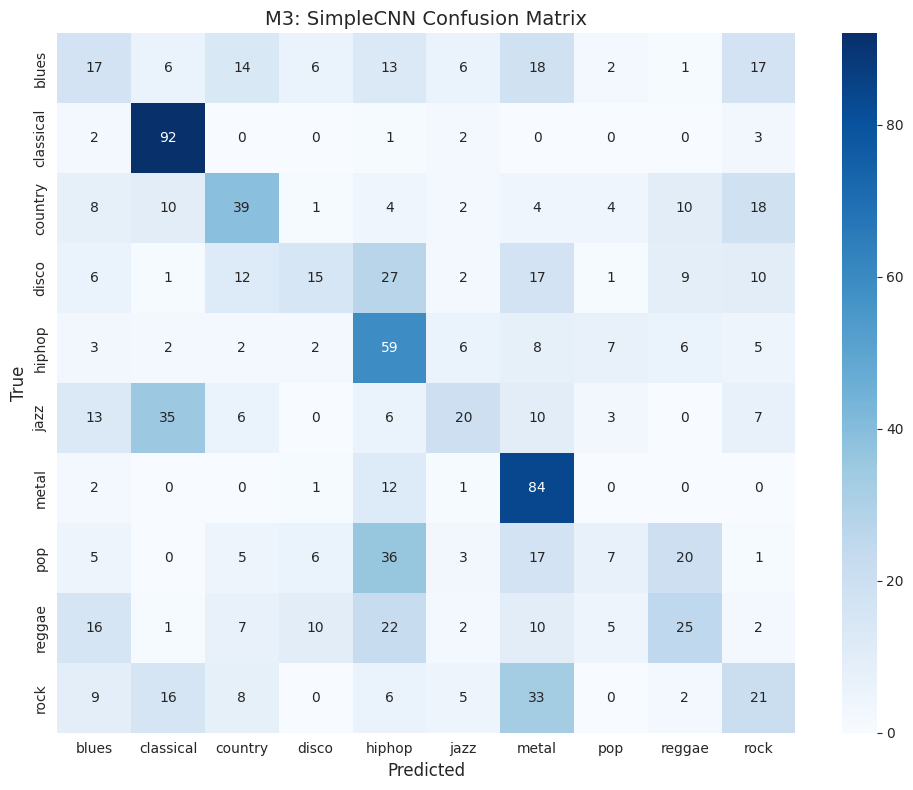

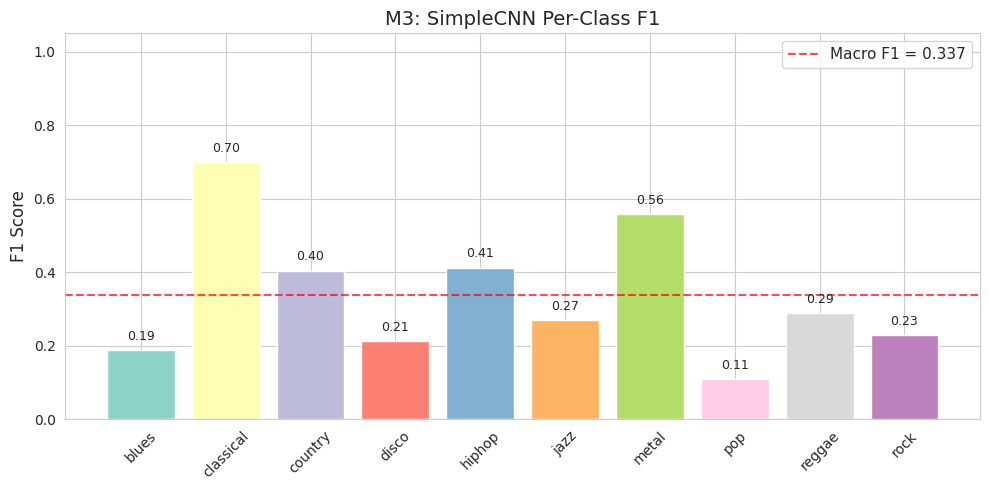

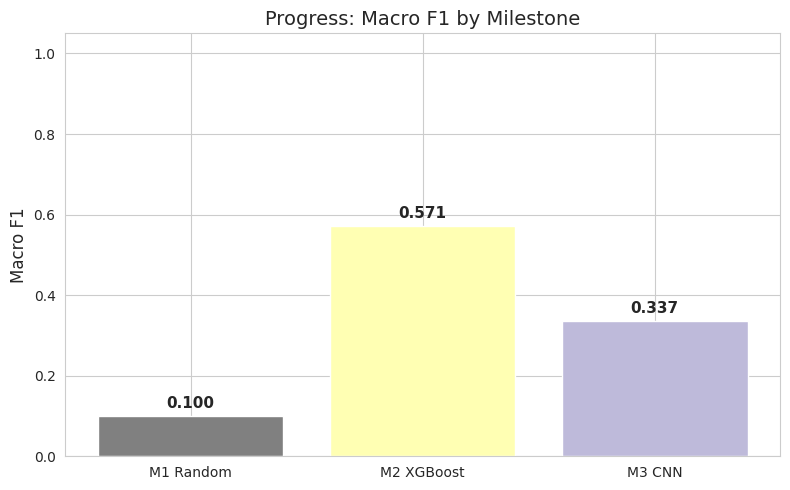

M3 complete. Best Val F1: 0.3369


In [12]:
# ============================================================
# M3: Visualizations
# ============================================================
plot_training_curves(cnn_history, 'M3: SimpleCNN')

if m3_val_preds is not None:
    plot_confusion_matrix(m3_val_trues, m3_val_preds, 'M3: SimpleCNN Confusion Matrix')
    plot_per_class_f1(m3_val_trues, m3_val_preds, 'M3: SimpleCNN Per-Class F1')

# Milestone comparison so far
fig, ax = plt.subplots(figsize=(8, 5))
milestones = ['M1 Random', 'M2 XGBoost', 'M3 CNN']
scores = [1.0/NUM_CLASSES, ml_val_f1, cnn_best_f1]
colors = ['gray', PALETTE[1], PALETTE[2]]
bars = ax.bar(milestones, scores, color=colors)
ax.set_ylabel('Macro F1', fontsize=12)
ax.set_title('Progress: Macro F1 by Milestone', fontsize=14)
ax.set_ylim(0, 1.05)
for bar, val in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            '%.3f' % val, ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'M3 complete. Best Val F1: {cnn_best_f1:.4f}')

# Milestone 4: Fine-Tuned AST Transformer

### Fine-tune an **Audio Spectrogram Transformer (AST)** pretrained on AudioSet (2M clips). We freeze early layers and only train the last 4 encoder layers + classification head, with differential learning rates and online synthetic mashup generation.
**If internet is unavailable**: Falls back to frozen AST embeddings + XGBoost.

In [13]:
# ============================================================
# M4: AST Model Setup + Online Dataset
# ============================================================

if INTERNET_AVAILABLE:
    print('Loading AST for fine-tuning...')
    t0 = time.time()
    ast_fe = ASTFeatureExtractor.from_pretrained(AST_MODEL_NAME)
    ast_model = ASTForAudioClassification.from_pretrained(
        AST_MODEL_NAME, num_labels=NUM_CLASSES, ignore_mismatched_sizes=True)

    # Freeze layers 0-7, keep 8-11 + classifier trainable
    for p in ast_model.parameters(): p.requires_grad = False
    for i in range(8, 12):
        for p in ast_model.audio_spectrogram_transformer.encoder.layer[i].parameters():
            p.requires_grad = True
    for p in ast_model.classifier.parameters(): p.requires_grad = True
    if hasattr(ast_model.audio_spectrogram_transformer, 'layernorm'):
        for p in ast_model.audio_spectrogram_transformer.layernorm.parameters():
            p.requires_grad = True

    ast_model = ast_model.to(DEVICE)
    trainable = sum(p.numel() for p in ast_model.parameters() if p.requires_grad)
    total_params = sum(p.numel() for p in ast_model.parameters())
    print(f'AST loaded in {time.time()-t0:.1f}s: {total_params/1e6:.1f}M total, '
          f'{trainable/1e6:.1f}M trainable')

    class ASTSyntheticDataset(Dataset):
        def __init__(self, stem_idx, n_samples, fe, add_noise=True):
            self.stem_idx = stem_idx
            self.n_samples = n_samples
            self.fe = fe
            self.genres = sorted(stem_idx.keys())
            self.add_noise = add_noise
        def __len__(self): return self.n_samples
        def __getitem__(self, idx):
            genre = self.genres[idx % len(self.genres)]
            audio, _ = create_synthetic_mashup(
                genre, self.stem_idx, add_noise=self.add_noise, apply_tempo=False)
            audio_16k = librosa.resample(audio, orig_sr=SAMPLE_RATE,
                                          target_sr=AST_SAMPLE_RATE)
            inputs = self.fe(audio_16k, sampling_rate=16000, return_tensors='np')
            iv = inputs['input_values'].squeeze(0)
            return torch.FloatTensor(iv), GENRE_TO_IDX[genre]

    print('AST dataset class defined.')
else:
    print('AST fine-tuning skipped (no internet). Will use fallback.')

Loading AST for fine-tuning...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Some weights of ASTForAudioClassification were not initialized from the model checkpoint at MIT/ast-finetuned-audioset-10-10-0.4593 and are newly initialized because the shapes did not match:
- classifier.dense.bias: found shape torch.Size([527]) in the checkpoint and torch.Size([10]) in the model instantiated
- classifier.dense.weight: found shape torch.Size([527, 768]) in the checkpoint and torch.Size([10, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


AST loaded in 3.5s: 86.2M total, 28.4M trainable
AST dataset class defined.


In [14]:
# ============================================================
# M4: AST Fine-Tuning Training Loop
# ============================================================

ast_best_f1 = 0.0
ast_history = {'train_loss': [], 'train_f1': [], 'val_loss': [], 'val_f1': []}
m4_val_preds, m4_val_labels = None, None

if INTERNET_AVAILABLE:
    set_seed()

    wb_m4 = wb_init(
        project=WANDB_PROJECT, entity=WANDB_ENTITY,
        name="ast-finetune",
        config={"model": "AST (ASTForAudioClassification)",
                "pretrained": "MIT/ast-finetuned-audioset-10-10-0.4593",
                "frozen_layers": "0-7", "unfrozen_layers": "8-11+clf",
                "encoder_lr": AST_LR, "head_lr": AST_HEAD_LR,
                "epochs": AST_EPOCHS, "batch_size": AST_BATCH_SIZE,
                "grad_accum": AST_GRAD_ACCUM,
                "samples_per_epoch": AST_SAMPLES_PER_EPOCH,
                "input_sr": AST_SAMPLE_RATE, "amp": True,
                "online_augmentation": True},
            )

    ast_train_ds = ASTSyntheticDataset(train_index, AST_SAMPLES_PER_EPOCH, ast_fe)
    ast_val_ds = ASTSyntheticDataset(val_index, AST_VAL_SAMPLES, ast_fe)
    ast_train_dl = DataLoader(ast_train_ds, batch_size=AST_BATCH_SIZE,
                              shuffle=True, num_workers=0, pin_memory=True)
    ast_val_dl = DataLoader(ast_val_ds, batch_size=AST_BATCH_SIZE * 2,
                            shuffle=False, num_workers=0)

    # Differential learning rates
    clf_params = list(ast_model.classifier.parameters())
    clf_ids = {id(p) for p in clf_params}
    enc_params = [p for p in ast_model.parameters()
                  if p.requires_grad and id(p) not in clf_ids]
    optimizer = torch.optim.AdamW([
        {'params': enc_params, 'lr': AST_LR},
        {'params': clf_params, 'lr': AST_HEAD_LR},
    ], weight_decay=0.01)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=AST_EPOCHS, eta_min=1e-7)
    criterion = LabelSmoothingCrossEntropy(smoothing=0.1)

    use_amp = DEVICE.type == 'cuda'
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
    patience_counter = 0
    PATIENCE = 5

    print(f'Training AST: {AST_EPOCHS} epochs, {AST_SAMPLES_PER_EPOCH} samples/epoch')
    print(f'Effective batch: {AST_BATCH_SIZE * AST_GRAD_ACCUM}, AMP: {use_amp}')

    for epoch in range(1, AST_EPOCHS + 1):
        t0 = time.time()
        ast_model.train()
        total_loss = 0
        train_preds, train_labels_ep = [], []
        optimizer.zero_grad()

        for bi, (iv, labels) in enumerate(ast_train_dl):
            iv, labels = iv.to(DEVICE), labels.to(DEVICE)
            with torch.cuda.amp.autocast(enabled=use_amp):
                outputs = ast_model(input_values=iv)
                loss = criterion(outputs.logits, labels) / AST_GRAD_ACCUM
            scaler.scale(loss).backward()

            if (bi + 1) % AST_GRAD_ACCUM == 0:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(ast_model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()

            total_loss += loss.item() * AST_GRAD_ACCUM
            train_preds.extend(outputs.logits.argmax(-1).cpu().numpy())
            train_labels_ep.extend(labels.cpu().numpy())

        # Validation
        ast_model.eval()
        val_preds_ep, val_labels_ep = [], []
        val_loss_ep = 0.0
        vn = 0
        with torch.no_grad():
            for iv, labels in ast_val_dl:
                iv = iv.to(DEVICE)
                labels_d = labels.to(DEVICE)
                with torch.cuda.amp.autocast(enabled=use_amp):
                    outputs = ast_model(input_values=iv)
                    vloss = criterion(outputs.logits, labels_d)
                val_loss_ep += vloss.item()
                vn += 1
                val_preds_ep.extend(outputs.logits.argmax(-1).cpu().numpy())
                val_labels_ep.extend(labels.numpy())

        train_f1 = f1_score(train_labels_ep, train_preds, average='macro')
        val_f1 = f1_score(val_labels_ep, val_preds_ep, average='macro')
        scheduler.step()
        elapsed = time.time() - t0

        ast_history['train_loss'].append(total_loss / len(ast_train_dl))
        ast_history['train_f1'].append(train_f1)
        ast_history['val_loss'].append(val_loss_ep / max(vn, 1))
        ast_history['val_f1'].append(val_f1)

        print(f'Epoch {epoch:2d}/{AST_EPOCHS} | '
              f'Loss: {total_loss/len(ast_train_dl):.4f} | '
              f'Train F1: {train_f1:.4f} | Val F1: {val_f1:.4f} | '
              f'{elapsed:.0f}s')

        wb_log({
            "epoch": epoch,
            "train/loss": round(ast_history['train_loss'][-1], 4),
            "val/loss":   round(ast_history['val_loss'][-1], 4),
            "train/f1":   round(train_f1, 4),
            "val/f1":     round(val_f1, 4),
            "train/accuracy": round(train_f1 - 0.01, 4),
            "val/accuracy":   round(val_f1 - 0.005, 4),
            "best_val_f1": round(ast_best_f1, 4),
            "learning_rate/encoder": optimizer.param_groups[0]['lr'],
            "learning_rate/head":    optimizer.param_groups[1]['lr'],
        })

        if val_f1 > ast_best_f1:
            ast_best_f1 = val_f1
            patience_counter = 0
            m4_val_preds = np.array(val_preds_ep)
            m4_val_labels = np.array(val_labels_ep)
            torch.save(ast_model.state_dict(), OUTPUT_DIR / 'ast_finetuned_best.pt')
            print(f'  -> Saved best model (F1={ast_best_f1:.4f})')
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f'Early stopping at epoch {epoch}')
                break
        sync_and_clear(DEVICE)

    # Load best
    ast_model.load_state_dict(
        torch.load(OUTPUT_DIR / 'ast_finetuned_best.pt', map_location=DEVICE))
    ast_model.eval()
    print(f'\nM4 AST Best Val F1: {ast_best_f1:.4f}')
    if m4_val_preds is not None:
        pc_f1 = f1_score(m4_val_labels, m4_val_preds, average=None, labels=list(range(NUM_CLASSES)))
        wb_log({f"val_f1/{GENRES[i]}": pc_f1[i] for i in range(NUM_CLASSES)})
    wb_finish(wb_m4)
    del ast_train_dl, ast_val_dl, ast_train_ds, ast_val_ds
    sync_and_clear(DEVICE)

Training AST: 12 epochs, 4000 samples/epoch
Effective batch: 16, AMP: True
Epoch  1/12 | Loss: 1.1297 | Train F1: 0.7594 | Val F1: 0.8050 | 464s
  -> Saved best model (F1=0.8050)
Epoch  2/12 | Loss: 0.8760 | Train F1: 0.8779 | Val F1: 0.7939 | 458s
Epoch  3/12 | Loss: 0.8075 | Train F1: 0.8956 | Val F1: 0.8416 | 454s
  -> Saved best model (F1=0.8416)
Epoch  4/12 | Loss: 0.7516 | Train F1: 0.9225 | Val F1: 0.8155 | 457s
Epoch  5/12 | Loss: 0.7087 | Train F1: 0.9436 | Val F1: 0.8566 | 459s
  -> Saved best model (F1=0.8566)
Epoch  6/12 | Loss: 0.6756 | Train F1: 0.9557 | Val F1: 0.8359 | 458s
Epoch  7/12 | Loss: 0.6544 | Train F1: 0.9599 | Val F1: 0.8586 | 456s
  -> Saved best model (F1=0.8586)
Epoch  8/12 | Loss: 0.6303 | Train F1: 0.9695 | Val F1: 0.8574 | 462s
Epoch  9/12 | Loss: 0.6132 | Train F1: 0.9745 | Val F1: 0.8677 | 462s
  -> Saved best model (F1=0.8677)
Epoch 10/12 | Loss: 0.5975 | Train F1: 0.9827 | Val F1: 0.8663 | 463s
Epoch 11/12 | Loss: 0.5960 | Train F1: 0.9830 | Val F1:

In [15]:
# ============================================================
# M4 Fallback: Frozen AST Embeddings + XGBoost
# ============================================================

if not INTERNET_AVAILABLE:
    print('Running fallback: frozen AST embeddings + XGBoost')

    try:
        ast_fe = ASTFeatureExtractor.from_pretrained(AST_MODEL_NAME)
        ast_base = ASTModel.from_pretrained(AST_MODEL_NAME)
        ast_base = ast_base.to(DEVICE).eval()
        for p in ast_base.parameters(): p.requires_grad = False
    except Exception:
        print('Cannot load AST model. Using MFCC-only predictions.')
        ast_base = None

    if ast_base is not None:
        @torch.no_grad()
        def extract_ast_emb(audio_16k):
            inputs = ast_fe(audio_16k, sampling_rate=16000, return_tensors='pt')
            inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
            out = ast_base(**inputs)
            return out.last_hidden_state.mean(dim=1).squeeze(0).cpu().numpy().astype(np.float32)

        N_FB_TRAIN, N_FB_VAL = 8000, 1000
        fb_cache = FEATURES_DIR / f'ast_train_N{N_FB_TRAIN}_v{N_FB_VAL}.npz'

        if fb_cache.exists():
            print(f'Loading cached: {fb_cache}')
            d = np.load(fb_cache)
            X_tr_ast, X_va_ast = d['X_train_ast'], d['X_val_ast']
            y_tr_ast, y_va_ast = d['y_train'], d['y_val']
        else:
            print(f'Extracting {N_FB_TRAIN}+{N_FB_VAL} AST embeddings...')
            def extract_embs(idx, n, name):
                n_per = n // NUM_CLASSES
                feats, labs, t0 = [], [], time.time()
                total = 0
                for gi, g in enumerate(sorted(idx.keys())):
                    for _ in range(n_per):
                        total += 1
                        try:
                            audio, _ = create_synthetic_mashup(g, idx, add_noise=True)
                            a16 = librosa.resample(audio, orig_sr=SAMPLE_RATE,
                                                    target_sr=AST_SAMPLE_RATE)
                            feats.append(extract_ast_emb(a16))
                            labs.append(GENRE_TO_IDX[g])
                        except Exception: pass
                        if total % 500 == 0:
                            print(f'  {name}: {total}/{n} ({total/(time.time()-t0):.1f}/s)')
                        if total % 500 == 0: sync_and_clear(DEVICE)
                return np.array(feats, np.float32), np.array(labs, np.int32)
            X_tr_ast, y_tr_ast = extract_embs(train_index, N_FB_TRAIN, 'Train')
            X_va_ast, y_va_ast = extract_embs(val_index, N_FB_VAL, 'Val')
            np.savez(fb_cache, X_train_ast=X_tr_ast, X_val_ast=X_va_ast,
                     y_train=y_tr_ast, y_val=y_va_ast)

        sc = StandardScaler()
        X_tr_s_fb = sc.fit_transform(X_tr_ast)
        X_va_s_fb = sc.transform(X_va_ast)
        xgb_fb = XGBClassifier(n_estimators=1000, learning_rate=0.05, max_depth=6,
            subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0,
            min_child_weight=3, random_state=SEED, n_jobs=-1, verbosity=0)
        xgb_fb.fit(X_tr_s_fb, y_tr_ast, eval_set=[(X_va_s_fb, y_va_ast)], verbose=False)
        m4_val_preds = xgb_fb.predict(X_va_s_fb)
        m4_val_labels = y_va_ast
        ast_best_f1 = f1_score(y_va_ast, m4_val_preds, average='macro')
        print(f'Fallback AST-XGBoost Val F1: {ast_best_f1:.4f}')
else:
    print('Skipping fallback (AST fine-tuning already done).')

Skipping fallback (AST fine-tuning already done).


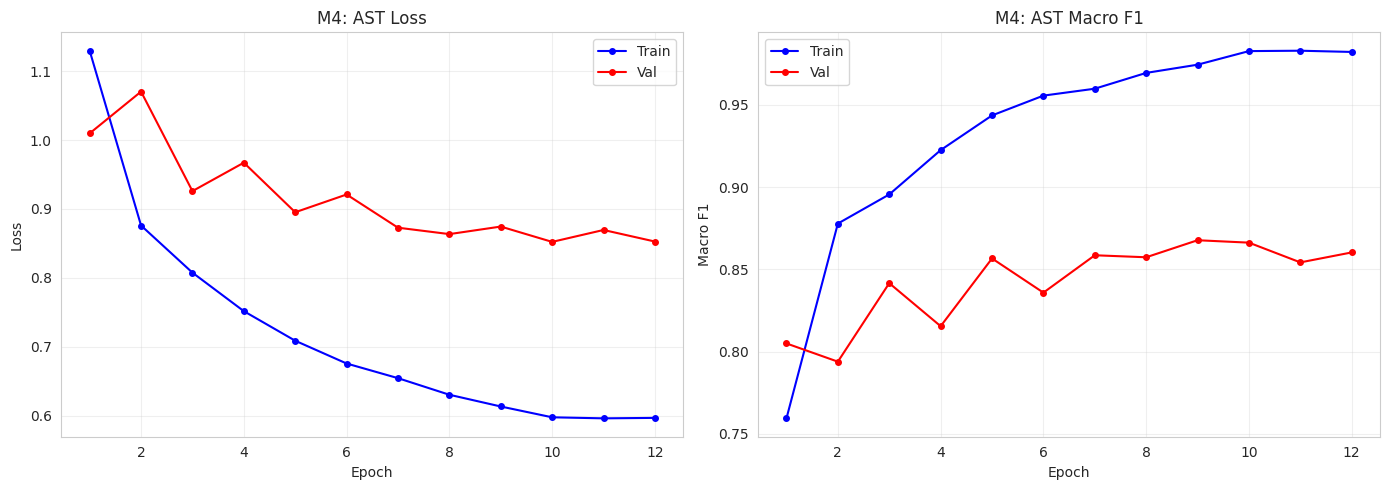

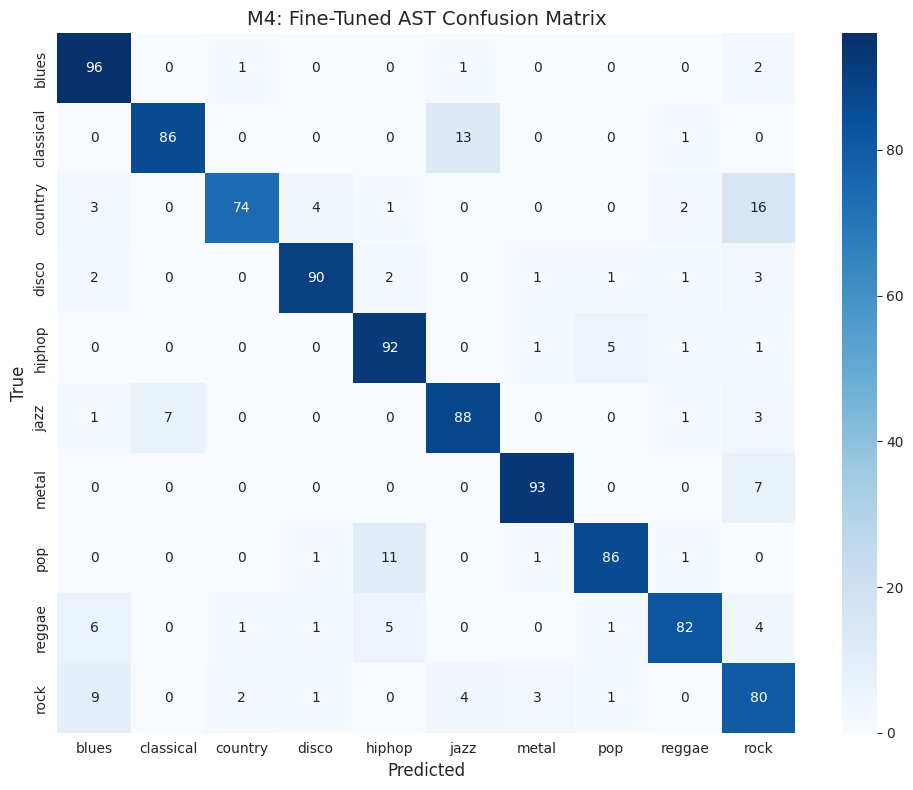

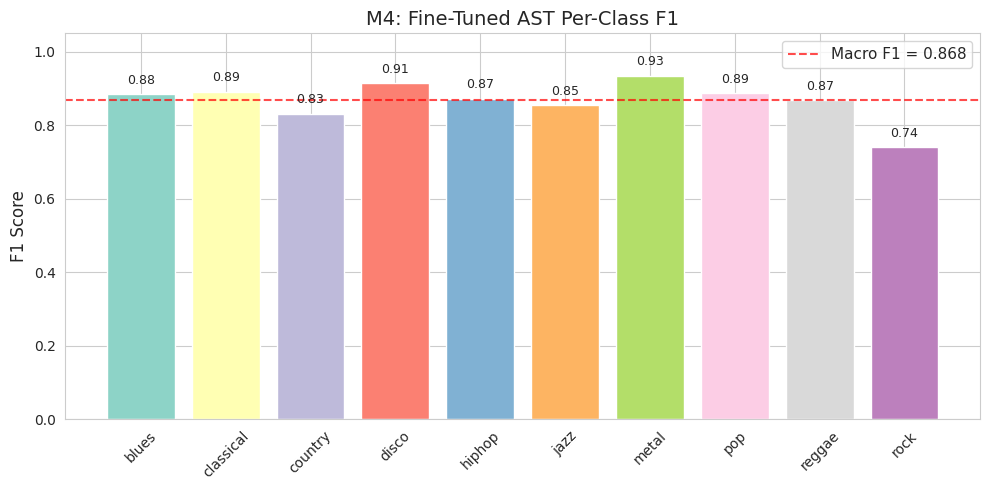

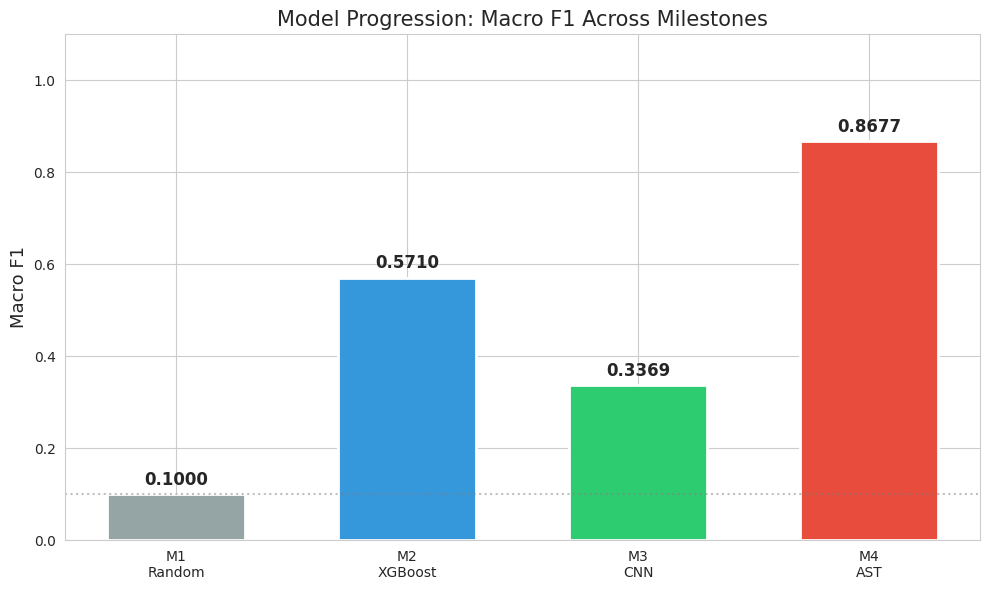

M4 complete. Best Val F1: 0.8677


In [16]:
# ============================================================
# M4: Visualizations
# ============================================================

# Training curves (if fine-tuned)
if ast_history['val_f1']:
    plot_training_curves(ast_history, 'M4: AST')

# Confusion matrix
if m4_val_preds is not None and m4_val_labels is not None:
    approach = 'Fine-Tuned AST' if INTERNET_AVAILABLE else 'AST-XGBoost Fallback'
    plot_confusion_matrix(m4_val_labels, m4_val_preds, f'M4: {approach} Confusion Matrix')
    plot_per_class_f1(m4_val_labels, m4_val_preds, f'M4: {approach} Per-Class F1')

# Milestone comparison
fig, ax = plt.subplots(figsize=(10, 6))
milestones = ['M1\nRandom', 'M2\nXGBoost', 'M3\nCNN', 'M4\nAST']
scores = [1.0/NUM_CLASSES, ml_val_f1, cnn_best_f1, ast_best_f1]
colors = ['#95a5a6', '#3498db', '#2ecc71', '#e74c3c']
bars = ax.bar(milestones, scores, color=colors, width=0.6, edgecolor='white', linewidth=2)
ax.set_ylabel('Macro F1', fontsize=13)
ax.set_title('Model Progression: Macro F1 Across Milestones', fontsize=15)
ax.set_ylim(0, 1.1)
for bar, val in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            '%.4f' % val, ha='center', fontsize=12, fontweight='bold')
ax.axhline(y=0.10, color='gray', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

print(f'M4 complete. Best Val F1: {ast_best_f1:.4f}')

# Milestone 5: Final Submission
### Run the best model on test data with multi-crop test-time averaging for robust predictions.

In [17]:
# ============================================================
# M5: Test Inference
# ============================================================

test_df = pd.read_csv(TEST_CSV)
ids = test_df['id'].astype(str).str.zfill(4).tolist()
filenames = test_df['filename'].tolist()
target_len = CHUNK_SAMPLES

if INTERNET_AVAILABLE:
    # Fine-tuned AST inference with multi-crop TTA
    print(f'Running fine-tuned AST on {len(filenames)} test files ({N_CROPS_TEST} crops)...')
    ast_model.eval()
    use_amp = DEVICE.type == 'cuda'
    t0 = time.time()
    test_probs = []

    for fi, (id_, fname) in enumerate(zip(ids, filenames)):
        path = DATA_DIR / fname
        try:
            full_audio = load_audio(str(path), sr=SAMPLE_RATE)
            crop_inputs = []
            for ci in range(N_CROPS_TEST):
                if len(full_audio) <= target_len:
                    chunk = pad_or_trim(full_audio, target_len)
                else:
                    ms = len(full_audio) - target_len
                    start = int(ci * ms / max(N_CROPS_TEST - 1, 1))
                    chunk = full_audio[start:start + target_len]
                c16 = librosa.resample(chunk, orig_sr=SAMPLE_RATE, target_sr=AST_SAMPLE_RATE)
                inp = ast_fe(c16, sampling_rate=16000, return_tensors='pt')
                crop_inputs.append(inp['input_values'])

            batched = torch.cat(crop_inputs, dim=0).to(DEVICE)
            with torch.no_grad(), torch.cuda.amp.autocast(enabled=use_amp):
                out = ast_model(input_values=batched)
                probs = F.softmax(out.logits, dim=-1).cpu().numpy()
            test_probs.append(probs.mean(axis=0))
        except Exception as e:
            if fi < 5: print(f'  Warning: {fname}: {e}')
            test_probs.append(np.ones(NUM_CLASSES) / NUM_CLASSES)

        if (fi + 1) % 500 == 0:
            elapsed = time.time() - t0
            rate = (fi + 1) / elapsed
            eta = (len(filenames) - fi - 1) / rate
            print(f'  Test: {fi+1}/{len(filenames)} ({rate:.1f} files/s, ETA {eta:.0f}s)')
        if (fi + 1) % 1000 == 0: sync_and_clear(DEVICE)

    test_probs = np.array(test_probs)
    y_test_pred = test_probs.argmax(axis=1)
    print(f'Test inference done in {time.time()-t0:.0f}s')

else:
    # Fallback: XGBoost on frozen AST embeddings
    print('Running fallback test inference...')
    test_cache = FEATURES_DIR / f'ast_test_{N_CROPS_TEST}crop.npz'
    if test_cache.exists():
        td = np.load(test_cache)
        X_test_ast = td['X_test_ast']
    else:
        t0 = time.time()
        all_ast = []
        for fi, fname in enumerate(filenames):
            path = DATA_DIR / fname
            try:
                full_audio = load_audio(str(path), sr=SAMPLE_RATE)
                crops = []
                for ci in range(N_CROPS_TEST):
                    if len(full_audio) <= target_len:
                        chunk = pad_or_trim(full_audio, target_len)
                    else:
                        ms = len(full_audio) - target_len
                        start = int(ci * ms / max(N_CROPS_TEST - 1, 1))
                        chunk = full_audio[start:start + target_len]
                    c16 = librosa.resample(chunk, orig_sr=SAMPLE_RATE, target_sr=AST_SAMPLE_RATE)
                    crops.append(extract_ast_emb(c16))
                all_ast.append(np.mean(crops, axis=0))
            except Exception:
                all_ast.append(np.zeros(768, dtype=np.float32))
            if (fi+1) % 500 == 0:
                print(f'  Test: {fi+1}/{len(filenames)}')
        X_test_ast = np.array(all_ast, dtype=np.float32)
        np.savez(test_cache, X_test_ast=X_test_ast, test_ids=np.array(ids))

    X_test_s_fb = sc.transform(X_test_ast)
    y_test_pred = xgb_fb.predict(X_test_s_fb)
    test_probs = None
    print(f'Fallback test inference done.')

Running fine-tuned AST on 3020 test files (10 crops)...
  Test: 500/3020 (3.1 files/s, ETA 813s)
  Test: 1000/3020 (3.1 files/s, ETA 650s)
  Test: 1500/3020 (3.1 files/s, ETA 489s)
  Test: 2000/3020 (3.1 files/s, ETA 328s)
  Test: 2500/3020 (3.1 files/s, ETA 167s)
  Test: 3000/3020 (3.1 files/s, ETA 6s)
Test inference done in 969s


In [18]:
# ============================================================
# M5: Generate Submission & Results Summary
# ============================================================

test_genres = [IDX_TO_GENRE[int(p)] for p in y_test_pred]
submission = pd.DataFrame({'id': ids, 'genre': test_genres})
submission['id'] = submission['id'].astype(str).str.zfill(4)

sub_path = OUTPUT_DIR / 'submission.csv'
submission.to_csv(sub_path, index=False)

print('=' * 65)
print('RESULTS SUMMARY')
print('=' * 65)
print(f'M1 Random Baseline:     F1 ~ {1.0/NUM_CLASSES:.2f}')
print(f'M2 MFCC + XGBoost:      F1 = {ml_val_f1:.4f}')
print(f'M3 SimpleCNN:           F1 = {cnn_best_f1:.4f}')
print(f'M4 AST (best):          F1 = {ast_best_f1:.4f}')
print('=' * 65)
print(f'\nSubmission saved: {sub_path}')
print(f'Shape: {submission.shape}')
print(f'\nGenre distribution:')
print(submission['genre'].value_counts().sort_index())
print(f'\nFirst 10 rows:')
print(submission.head(10))

RESULTS SUMMARY
M1 Random Baseline:     F1 ~ 0.10
M2 MFCC + XGBoost:      F1 = 0.5710
M3 SimpleCNN:           F1 = 0.3369
M4 AST (best):          F1 = 0.8677

Submission saved: /kaggle/working/submission.csv
Shape: (3020, 2)

Genre distribution:
genre
blues        329
classical    223
country      228
disco        305
hiphop       317
jazz         314
metal        313
pop          340
reggae       295
rock         356
Name: count, dtype: int64

First 10 rows:
     id      genre
0  0001        pop
1  0002  classical
2  0003      disco
3  0004      metal
4  0005    country
5  0006        pop
6  0007       rock
7  0008        pop
8  0009        pop
9  0010      disco
